# 🩺 NLP-Based Medical Symptom Checker with Severity Analysis
---
**Module:** CS7050NI — Artificial Intelligence <br>
**Author:** Sushil Shrestha  <br>
**LMU ID:** SUS1346  <br>


## What this notebook covers

This is the **single consolidated notebook** for the project.

1. **Dataset loading & EDA**: Symptom2Disease (1,200 rows · 24 disease classes).
2. **Severity triage mapping**: Clinically informed Mild / Moderate / Urgent layer.
3. **Technique 1**: Calibrated TF-IDF (word 1-2 grams) + Linear SVM.
4. **Technique 2**: TF-IDF (word + character 3-5 grams) + Logistic Regression.
5. **Model comparison**: Accuracy, precision, recall, F1, per-class F1.
6. **Severity-aware triage layer**: Model-map + clinical red-flag override.
7. **Longitudinal escalation detector**: The novel contribution of the project.
8. **Explainability** : Top-token drivers + top-3 differential diagnosis.
9. **Demo inference** : Replays `examples/sample_inputs.json` against the trained model.
10. **Optional Technique 3**: Pointer to the Colab BERT fine-tuning notebook.
11. **Streamlit app**: Pointer to the multi-page interactive UI.

> **How to run:** `Kernel → Restart & Run All`. All artefacts are written to
> `artifacts/` and figures to `figures/`. Re-running is idempotent.


## 1. Imports and reproducibility

In [113]:
import sys
import json
import random
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn — Technique 1, Technique 2, evaluation
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

import joblib

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
# Both random and numpy seeds must be set independently for full reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Notebook lives in notebook/ — resolve project root one level up.
# Handles both: `jupyter notebook` from / and from notebook/.
_cwd = Path('.').resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebook' else _cwd

# Make src/ and streamlit_web-app/ importable so we can reuse shared logic
for _sub in ('src', 'streamlit_web-app'):
    _p = str(PROJECT_ROOT / _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Output dirs (always relative to project root, not the notebook directory)
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
FIGURE_DIR = PROJECT_ROOT / 'figures'
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print('Imports OK · Seed =', RANDOM_SEED)
print('Project root:', PROJECT_ROOT)


Imports OK · Seed = 42
Project root: /Users/sushil/Masters/AI/coursework/NLP-Based-Symptom-Checker-with-Severity-Analysis


## 2. Severity triage mapping (clinical knowledge layer)

The Symptom2Disease dataset only contains disease labels no urgency / triage
information. To turn the classifier into something **actionable**, we add a
deterministic mapping from each disease to one of three triage levels:

| Level | Action |
|-------|--------|
| **Mild** | Self-care, monitor at home. |
| **Moderate** | See a GP within a few days. |
| **Urgent** | Seek care immediately. |

The mapping reflects WHO-style triage: e.g. *common cold → Mild*, *diabetes → Moderate*,
*pneumonia / dengue / jaundice → Urgent*. This is a small but real piece of clinical
knowledge engineering and is one of the **novel contributions** of the project.

We also keep a list of **red-flag phrases** (chest pain, shortness of breath, blood,
seizure, …). When any appear in the user's free text, severity is forced to *Urgent*
regardless of what the classifier says a defensive layer for the cases where the
ML model is uncertain but a human reading the text would clearly call an ambulance.

In [135]:
SEVERITY_MAP = {
    # Mild
    'common cold': 'Mild', 'allergy': 'Mild', 'acne': 'Mild',
    'fungal infection': 'Mild', 'psoriasis': 'Mild', 'migraine': 'Mild',
    # Moderate
    'bronchial asthma': 'Moderate', 'diabetes': 'Moderate',
    'hypertension': 'Moderate', 'cervical spondylosis': 'Moderate',
    'arthritis': 'Moderate', 'gastroesophageal reflux disease': 'Moderate',
    'peptic ulcer disease': 'Moderate', 'urinary tract infection': 'Moderate',
    'varicose veins': 'Moderate', 'chicken pox': 'Moderate',
    'drug reaction': 'Moderate', 'dimorphic hemorrhoids': 'Moderate',
    # Urgent
    'pneumonia': 'Urgent', 'dengue': 'Urgent', 'malaria': 'Urgent',
    'typhoid': 'Urgent', 'jaundice': 'Urgent', 'impetigo': 'Urgent',
}

SEVERITY_RANK = {'Mild': 0, 'Moderate': 1, 'Urgent': 2}
SEVERITY_COLOR = {'Mild': '#7fbf7b', 'Moderate': '#fdae61', 'Urgent': '#d73027'}

# Curated from WHO emergency-triage guidance + UK NHS 111 advice
RED_FLAGS = [
    'chest pain', 'shortness of breath', 'cannot breathe', "can't breathe",
    'cant breathe', 'breathless', 'unconscious', 'unresponsive', 'fainting',
    'fainted', 'seizure', 'stroke', 'blood in stool', 'blood in urine',
    'vomiting blood', 'coughing blood', 'severe bleeding', 'severe pain',
    'high fever', 'stiff neck', 'confusion', 'slurred speech',
    'numbness on one side', 'suicidal',
]

print(f'Severity map covers {len(SEVERITY_MAP)} disease classes.')
print(pd.Series(SEVERITY_MAP).value_counts().to_string())
print(f'\nRed-flag phrases tracked: {len(RED_FLAGS)}')


Severity map covers 24 disease classes.
Moderate    12
Mild         6
Urgent       6

Red-flag phrases tracked: 24


## 3. Dataset loading and preprocessing

**Symptom2Disease** (Niyarr Barman, Kaggle): 1,200 free-text symptom descriptions
labelled with one of 24 disease categories. Each row is a sentence/paragraph in
plain English, e.g. *"I have been experiencing a skin rash on my arms…"*.

Light cleaning: lowercase + strip punctuation + collapse whitespace. Labels are
normalised to lowercase as well the raw CSV mixes casings (`allergy`, `Diabetes`,
`Varicose Veins`) which would otherwise break the severity-map join.

In [115]:
import re

def clean_text(t):
    """Lowercase, drop non-alphanumerics, collapse whitespace."""
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

DATA_PATH = PROJECT_ROOT / 'dataset' / 'Symptom2Disease.csv'
df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df = df[['label', 'text']].dropna().reset_index(drop=True)
df['label_norm'] = df['label'].str.lower().str.strip()
df['clean_text'] = df['text'].apply(clean_text)
df['severity'] = df['label_norm'].map(SEVERITY_MAP).fillna('Moderate')

print(f'Loaded {len(df)} rows · {df["label_norm"].nunique()} classes')
df.head(5)


Loaded 1200 rows · 24 classes


,label,text,label_norm,clean_text,severity
0,Psoriasis,I have been experiencing a skin rash on my arm...,psoriasis,i have been experiencing a skin rash on my arm...,Mild
1,Psoriasis,"My skin has been peeling, especially on my kne...",psoriasis,my skin has been peeling especially on my knee...,Mild
2,Psoriasis,I have been experiencing joint pain in my fing...,psoriasis,i have been experiencing joint pain in my fing...,Mild
3,Psoriasis,"There is a silver like dusting on my skin, esp...",psoriasis,there is a silver like dusting on my skin espe...,Mild
4,Psoriasis,"My nails have small dents or pits in them, and...",psoriasis,my nails have small dents or pits in them and ...,Mild


## 4. Exploratory data analysis

A few quick sanity checks: class balance, severity distribution, and text length. <br>
The dataset is **balanced** 50 examples per disease which is unusual for
medical NLP and convenient for evaluation (macro F1 is meaningful).

In [136]:
print('Total samples:', len(df))
print('Disease classes:', df['label_norm'].nunique())
print('Per-class min / max:', df['label_norm'].value_counts().min(), '/', df['label_norm'].value_counts().max())
print('\nSeverity distribution:')
print(df['severity'].value_counts().to_string())
print('\nText length (chars) — mean / median / max:',
      int(df['text'].str.len().mean()),
      int(df['text'].str.len().median()),
      int(df['text'].str.len().max()))


Total samples: 1200
Disease classes: 24
Per-class min / max: 50 / 50

Severity distribution:
severity
Moderate    600
Mild        300
Urgent      300

Text length (chars) — mean / median / max: 171 170 317


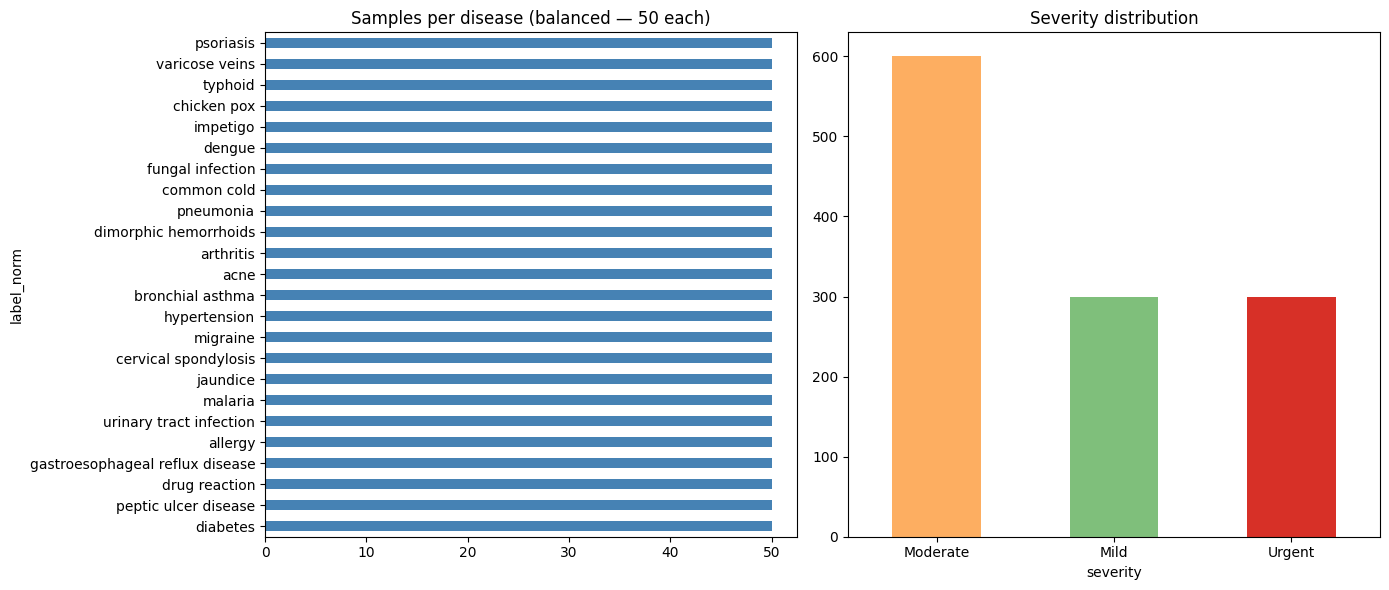

Saved figures/eda_distribution.png


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df['label_norm'].value_counts().plot(
    kind='barh', ax=axes[0], color='steelblue'
)

axes[0].set_title('Samples per disease (balanced — 50 each)')
axes[0].invert_yaxis()

df['severity'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=[SEVERITY_COLOR[s] for s in df['severity'].value_counts().index],
)
axes[1].set_title('Severity distribution')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_distribution.png', dpi=150)
plt.show()

print('Saved figures/eda_distribution.png')


## 5. Stratified Train / Test split

70 / 30 split, stratified by disease label so every class is represented in both
splits. The same split is used for both AI techniques to make the comparison fair.

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_norm'],
    test_size=0.30, random_state=RANDOM_SEED, stratify=df['label_norm'],
)
print(f'Train: {len(X_train)} · Test: {len(X_test)}')


Train: 840 · Test: 360


## 6. Technique 1: TF-IDF (word 1-2g) + Calibrated LinearSVC

A strong **linear baseline** for short medical text. Plain `LinearSVC` doesn't expose
`predict_proba`, so we wrap it in `CalibratedClassifierCV` with Platt scaling — that
gives us proper probabilities for the **top-3 differential diagnosis** the Streamlit
app uses. This matters in medical triage: clinicians rarely commit to one diagnosis
from a sentence of symptoms; they reason over a short ranked list.

In [137]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ('svm',   CalibratedClassifierCV(
        LinearSVC(C=1.0, random_state=RANDOM_SEED),
        cv=3, method='sigmoid',
    )),
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

svm_metrics = {
    'accuracy':         accuracy_score(y_test, y_pred_svm),
    'precision_macro':  precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
    'recall_macro':     recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
    'f1_macro':         f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
}
for k, v in svm_metrics.items():
    print(f'SVM   {k:<18}: {v:.4f}')

# Persist the calibrated pipeline — the Streamlit app loads this exact file
joblib.dump(svm_pipeline, ARTIFACT_DIR / 'calibrated_svm_pipeline.joblib')
print(f'\nSaved → artifacts/calibrated_svm_pipeline.joblib')


SVM   accuracy          : 0.9472
SVM   precision_macro   : 0.9509
SVM   recall_macro      : 0.9472
SVM   f1_macro          : 0.9464

Saved → artifacts/calibrated_svm_pipeline.joblib


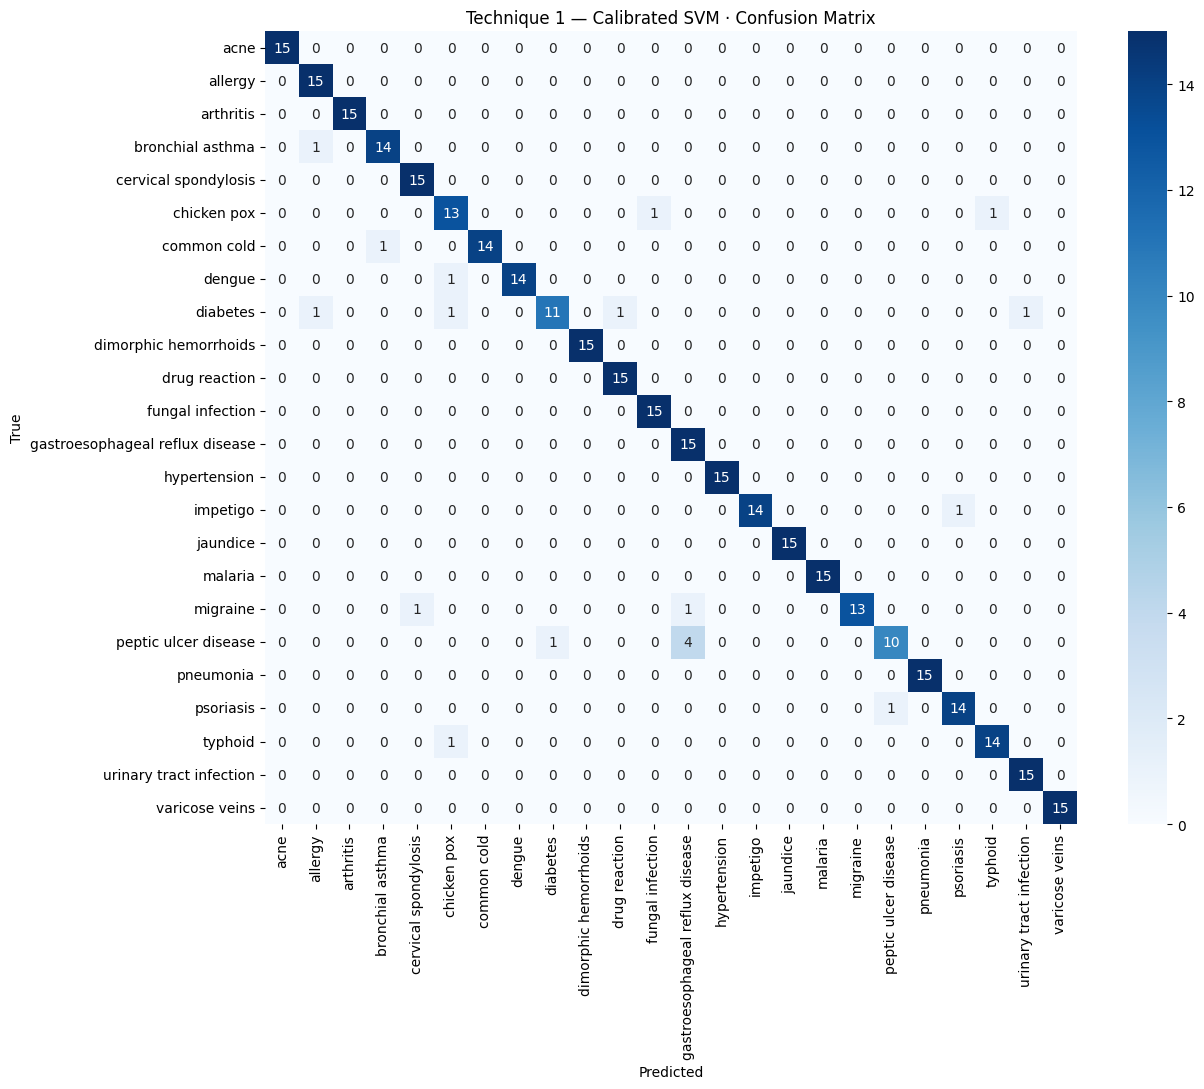

In [ ]:
# Confusion matrix
labels_sorted = sorted(df['label_norm'].unique())
cm = confusion_matrix(y_test, y_pred_svm, labels=labels_sorted)

plt.figure(figsize=(13, 11))
sns.heatmap(
    cm, xticklabels=labels_sorted, yticklabels=labels_sorted,
    cmap='Blues', annot=True, fmt='d', cbar=True,
)
plt.title('Technique 1 — Calibrated SVM · Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'svm_confusion_matrix.png', dpi=150)
plt.show()


## 7. Technique 2: TF-IDF (word + char 3-5g) + Logistic Regression

This is a **genuinely different** technique, not just a different classifier on the
same features:

* **Feature union**: Word 1-2 grams ∪ character 3-5 grams (`analyzer='char_wb'`).
  Character n-grams capture morphological cues that pure word features miss
  e.g. *itch · itchy · itching · scratching* share substrings, *pneumon* is a
  shared character pattern across pneumonia variants.
* **Optimiser**: L2-regularised logistic regression with `class_weight='balanced'`
  to be robust if the dataset ever becomes imbalanced.
* **Why this pairing satisfies "two AI techniques"**: different feature space and
  different decision rule (max-likelihood logistic vs hinge-loss SVM).

In [121]:
word_tfidf = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=2, sublinear_tf=True,
)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), min_df=2, sublinear_tf=True,
)
union = FeatureUnion([('word', word_tfidf), ('char', char_tfidf)])

logreg_pipeline = Pipeline([
    ('features', union),
    ('logreg', LogisticRegression(
        max_iter=2000, C=4.0, class_weight='balanced',
        solver='lbfgs', n_jobs=-1, random_state=RANDOM_SEED,
    )),
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)

lr_metrics = {
    'accuracy':         accuracy_score(y_test, y_pred_lr),
    'precision_macro':  precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
    'recall_macro':     recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
    'f1_macro':         f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
}
for k, v in lr_metrics.items():
    print(f'LogReg {k:<18}: {v:.4f}')

joblib.dump(logreg_pipeline, ARTIFACT_DIR / 'logreg_pipeline.joblib')
print(f'\nSaved → artifacts/logreg_pipeline.joblib')


LogReg accuracy          : 0.9722
LogReg precision_macro   : 0.9739
LogReg recall_macro      : 0.9722
LogReg f1_macro          : 0.9721

Saved → artifacts/logreg_pipeline.joblib


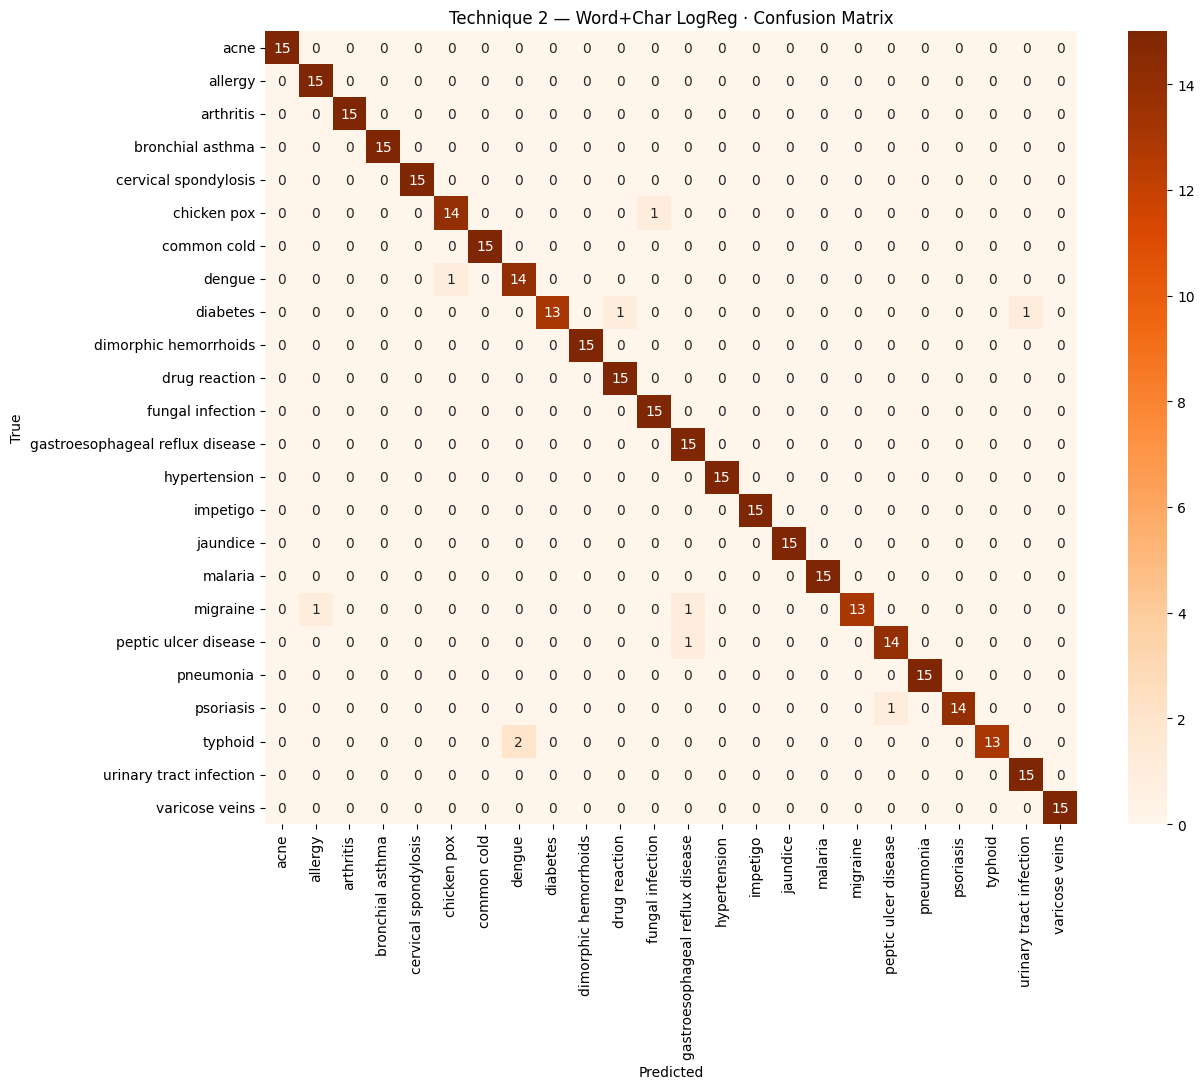

In [122]:
# LogReg confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels_sorted)

plt.figure(figsize=(13, 11))
sns.heatmap(
    cm_lr, xticklabels=labels_sorted, yticklabels=labels_sorted,
    cmap='Oranges', annot=True, fmt='d', cbar=True,
)
plt.title('Technique 2 — Word+Char LogReg · Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'logreg_confusion_matrix.png', dpi=150)
plt.show()


## 8. Model comparison (the headline result)

Side-by-side metrics on the held-out 30% test split. **All four metrics on the same
chart** so the paper has one figure that tells the whole story.

In [123]:
comparison = {
    'TF-IDF (word 1-2g) + Calibrated LinearSVC': svm_metrics,
    'TF-IDF (word + char 3-5g) + Logistic Regression': lr_metrics,
}
metrics_df = pd.DataFrame(comparison).T
metrics_df.columns = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
print('Headline comparison:')
metrics_df.round(4)


Headline comparison:


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
TF-IDF (word 1-2g) + Calibrated LinearSVC,0.9472,0.9509,0.9472,0.9464
TF-IDF (word + char 3-5g) + Logistic Regression,0.9722,0.9739,0.9722,0.9721


In [124]:
# Save combined metrics JSON for the paper / Streamlit app
comparison_json = {
    'trained_at': datetime.now(timezone.utc).isoformat(),
    'n_classes': int(df['label_norm'].nunique()),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'models': {
        'svm_tfidf': {'name': 'TF-IDF (word 1-2g) + Calibrated LinearSVC', **svm_metrics},
        'logreg_charword': {'name': 'TF-IDF (word + char 3-5g) + Logistic Regression', **lr_metrics},
    },
}
(ARTIFACT_DIR / 'model_comparison.json').write_text(json.dumps(comparison_json, indent=2, default=float))
print('Wrote artifacts/model_comparison.json')


Wrote artifacts/model_comparison.json


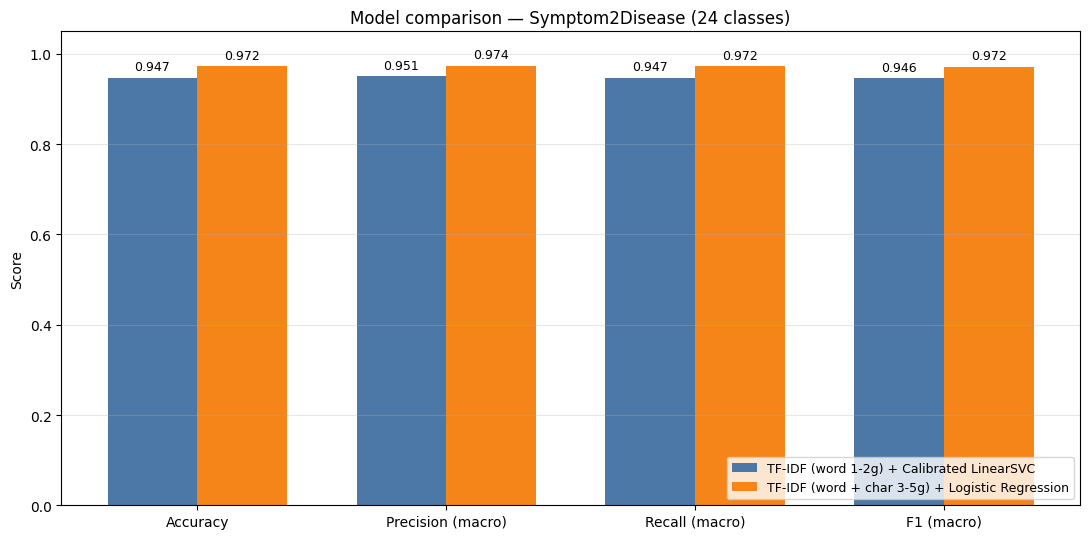

In [125]:
# Combined comparison plot
metrics_keys = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
labels = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
names = list(comparison.keys())
values = np.array([[comparison[n][k] for k in metrics_keys] for n in names])

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(metrics_keys))
width = 0.36
palette = ['#4C78A8', '#F58518']

for i, (n, row) in enumerate(zip(names, values)):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, row, width, label=n, color=palette[i])
    for b, v in zip(bars, row):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model comparison — Symptom2Disease (24 classes)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'model_comparison.png', dpi=150)
plt.show()


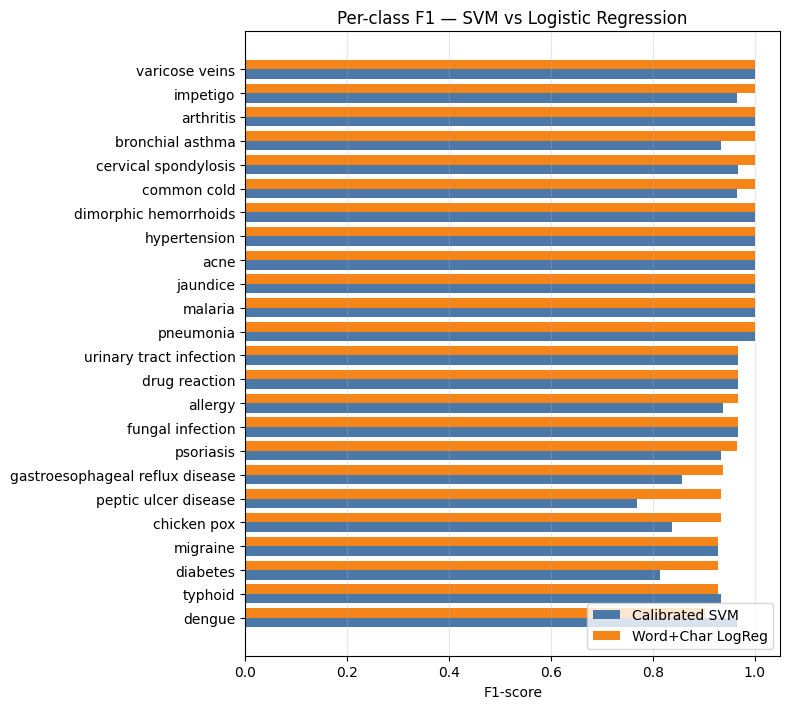

In [126]:
# Per-class F1 — useful for the error-analysis section of the paper
svm_report = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)
classes = sorted([k for k in svm_report.keys() if k not in ('accuracy', 'macro avg', 'weighted avg')])

per_class_df = pd.DataFrame({
    'SVM F1':    [svm_report[c]['f1-score'] for c in classes],
    'LogReg F1': [lr_report[c]['f1-score']  for c in classes],
}, index=classes).sort_values('LogReg F1')

fig, ax = plt.subplots(figsize=(8, max(6, 0.3 * len(classes))))
yp = np.arange(len(classes))
ax.barh(yp - 0.2, per_class_df['SVM F1'].values,    height=0.4, label='Calibrated SVM', color='#4C78A8')
ax.barh(yp + 0.2, per_class_df['LogReg F1'].values, height=0.4, label='Word+Char LogReg', color='#F58518')
ax.set_yticks(yp); ax.set_yticklabels(per_class_df.index)
ax.set_xlim(0, 1.05); ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 — SVM vs Logistic Regression')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'per_class_f1.png', dpi=150)
plt.show()


## 9. Severity-aware triage layer

1. **Disease → severity mapping** (Section 2 above).
2. **Red-flag override** — if the user's free text contains any phrase from
   `RED_FLAGS`, severity is forced to *Urgent* regardless of the disease prediction.

This makes the system fail-safe: even if the classifier is uncertain, dangerous
phrases like *"chest pain"* always escalate.

Severity triage accuracy on test set: 0.8944

Severity confusion matrix:
          Mild  Moderate  Urgent
Mild        78         1      11
Moderate     1       155      24
Urgent       0         1      89


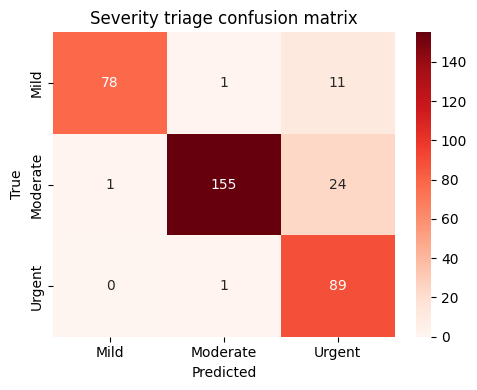

In [139]:
def detect_red_flags(text):
    text_l = text.lower()
    return [flag for flag in RED_FLAGS if flag in text_l]

def severity_for(label, raw_text):
    """Return Mild/Moderate/Urgent + the source of the decision."""
    if detect_red_flags(raw_text):
        return 'Urgent', 'red_flag_override'
    return SEVERITY_MAP.get(label, 'Moderate'), 'model_map'

# Evaluate severity-layer agreement on the test set
y_pred_severity = []
y_true_severity = []
for true_label, pred_label, raw in zip(y_test, y_pred_lr, X_test):
    sev, _ = severity_for(pred_label, raw)
    y_pred_severity.append(sev)
    y_true_severity.append(SEVERITY_MAP.get(true_label, 'Moderate'))

sev_acc = accuracy_score(y_true_severity, y_pred_severity)
print(f'Severity triage accuracy on test set: {sev_acc:.4f}')

sev_labels = ['Mild', 'Moderate', 'Urgent']
sev_cm = confusion_matrix(y_true_severity, y_pred_severity, labels=sev_labels)
print('\nSeverity confusion matrix:')
print(pd.DataFrame(sev_cm, index=sev_labels, columns=sev_labels))

plt.figure(figsize=(5, 4))
sns.heatmap(
    sev_cm, xticklabels=sev_labels, yticklabels=sev_labels,
    annot=True, fmt='d', cmap='Reds',
)
plt.title('Severity triage confusion matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'severity_confusion_matrix.png', dpi=150)
plt.show()


## 10. Longitudinal escalation detector

Every public Symptom2Disease prototype answers a one-shot question (*"What disease is this?"*). <br>
Real triage is **longitudinal** — symptoms evolve over hours and days. <br>
The escalation detector inspects a sliding window of journal entries and returns one of:

| Verdict | Trigger |
|---------|---------|
| **🚨 Escalate** | Any Urgent entry in the window, or severity rising over time. |
| **⚠️ Watch** | Same elevated severity (≥ Moderate) holding for ≥ 2 entries. |
| **✅ Stable** | Otherwise. |

The rules are **transparent** so the verdict can be defended in the paper —
not a black box.

In [128]:
from dataclasses import dataclass

@dataclass
class EscalationVerdict:
    level: str
    reason: str
    last_n: int
    delta_severity: int

def detect_escalation(severity_sequence, window=3):
    if not severity_sequence:
        return EscalationVerdict('Stable', 'No entries logged yet.', 0, 0)
    recent = severity_sequence[-window:]
    ranks = [SEVERITY_RANK[s] for s in recent]
    delta = ranks[-1] - ranks[0]

    if any(s == 'Urgent' for s in recent):
        return EscalationVerdict(
            'Escalate',
            'An Urgent severity entry was logged in the recent window — seek care now.',
            len(recent), delta,
        )
    if delta >= 1:
        return EscalationVerdict(
            'Escalate',
            f'Severity is trending upward ({recent[0]} -> {recent[-1]}).',
            len(recent), delta,
        )
    if max(ranks) >= 1 and len(recent) >= 2:
        return EscalationVerdict(
            'Watch',
            'Symptoms are persisting at a moderate level — monitor closely.',
            len(recent), delta,
        )
    return EscalationVerdict('Stable', 'Symptoms appear mild and not worsening.', len(recent), delta)

# Demo: simulate a session that escalates over 24h
demo_sessions = [
    ('Stable session',   ['Mild', 'Mild', 'Mild']),
    ('Watch session',    ['Mild', 'Moderate', 'Moderate']),
    ('Escalate by trend',['Mild', 'Moderate', 'Urgent']),
    ('Escalate red flag',['Mild', 'Mild', 'Urgent']),
]
for name, seq in demo_sessions:
    v = detect_escalation(seq)
    print(f'{name:<22} {seq}  →  {v.level:<8} ({v.reason})')


Stable session         ['Mild', 'Mild', 'Mild']  →  Stable   (Symptoms appear mild and not worsening.)
Watch session          ['Mild', 'Moderate', 'Moderate']  →  Escalate (Severity is trending upward (Mild -> Moderate).)
Escalate by trend      ['Mild', 'Moderate', 'Urgent']  →  Escalate (An Urgent severity entry was logged in the recent window — seek care now.)
Escalate red flag      ['Mild', 'Mild', 'Urgent']  →  Escalate (An Urgent severity entry was logged in the recent window — seek care now.)


## 11. Explainability: Top driver tokens + top-3 differential

For every prediction we surface:

* **Top-3 differential**: the three most likely diseases with calibrated probabilities.
* **Top driver tokens**: the words/bigrams in the user's text that pushed the model
  toward its prediction. We compute this as the elementwise product of the input's
  TF-IDF vector and the SVM's coefficient vector for the predicted class. It's a
  cheap but honest local explanation that maps directly back to words the user typed.

In [129]:
def top_drivers(pipe, text, top_k=5):
    """Return the top tokens in `text` that drove the predicted class."""
    vec = pipe.named_steps['tfidf']
    cal = pipe.named_steps['svm']
    feat_names = vec.get_feature_names_out()
    x_vec = vec.transform([text])

    pred_class = cal.predict(x_vec)[0]
    class_idx = list(cal.classes_).index(pred_class)
    coefs = []
    for cc in cal.calibrated_classifiers_:
        est = getattr(cc, 'estimator', None) or getattr(cc, 'base_estimator', None)
        if est is None or not hasattr(est, 'coef_'): continue
        coefs.append(est.coef_[class_idx])
    if not coefs: return []
    avg_coef = np.mean(np.vstack(coefs), axis=0)
    x_arr = x_vec.toarray()[0]
    scores = x_arr * avg_coef
    nonzero = np.where(x_arr > 0)[0]
    ranked = sorted(nonzero, key=lambda i: -scores[i])[:top_k]
    return [(feat_names[i], float(scores[i])) for i in ranked if scores[i] > 0]

def predict_full(text, pipe=svm_pipeline):
    """Return disease, top-3 differential, drivers, severity + source, red-flags."""
    cleaned = clean_text(text)
    proba = pipe.predict_proba([cleaned])[0]
    classes = list(pipe.classes_)
    order = np.argsort(-proba)
    top3 = [(classes[i], float(proba[i])) for i in order[:3]]
    sev, src = severity_for(top3[0][0], text)
    return {
        'disease': top3[0][0], 'confidence': top3[0][1],
        'differential': top3, 'drivers': top_drivers(pipe, cleaned),
        'severity': sev, 'severity_source': src,
        'red_flags': detect_red_flags(text),
    }


## 12. [Optional] Demo inference: Replay `examples/sample_inputs.json`

Replays the curated example inputs through the trained Calibrated SVM pipeline.
This is the **example I/O** required by the brief and is also a useful regression test.

In [130]:
_json_path = PROJECT_ROOT / 'examples' / 'sample_inputs.json'
if _json_path.exists():
    samples = json.loads(_json_path.read_text())['examples']
else:
    # Fallback hard-coded inputs so the notebook runs without the JSON file
    samples = [
        {'id': 'common_cold',            'input': 'I have a runny nose, sore throat and mild cough since yesterday.'},
        {'id': 'cardiac_emergency',      'input': 'Severe chest pain and shortness of breath, sweating a lot.'},
        {'id': 'uti',                    'input': 'Burning urination and frequent urge to go to the bathroom.'},
        {'id': 'jaundice',               'input': 'Yellow skin, dark urine and constant fatigue for a week.'},
        {'id': 'malaria_high_fever_red_flag', 'input': 'High cyclic fever with shaking chills and severe pain in muscles.'},
        {'id': 'chickenpox',             'input': 'Itchy red blisters all over body with mild fever.'},
    ]
    print('[examples/sample_inputs.json not found — using built-in fallback inputs]')

results = []
for ex in samples:
    out = predict_full(ex['input'])
    results.append({
        'id': ex['id'],
        'input': ex['input'],
        'predicted_disease': out['disease'],
        'confidence': round(out['confidence'], 3),
        'severity': out['severity'],
        'severity_source': out['severity_source'],
        'top3': out['differential'],
        'drivers': [t for t, _ in out['drivers']],
        'red_flags': out['red_flags'],
    })

demo_df = pd.DataFrame(results)[['id', 'predicted_disease', 'confidence', 'severity', 'severity_source', 'red_flags']]
print('Demo predictions:')
demo_df


Demo predictions:


,id,predicted_disease,confidence,severity,severity_source,red_flags
0,common_cold,allergy,0.843,Mild,model_map,[]
1,cardiac_emergency,pneumonia,0.388,Urgent,red_flag_override,"[chest pain, shortness of breath]"
2,uti,urinary tract infection,0.240,Moderate,model_map,[]
3,jaundice,jaundice,0.575,Urgent,model_map,[]
4,malaria_high_fever_red_flag,pneumonia,0.313,Urgent,red_flag_override,"[severe pain, high fever]"
5,chickenpox,chicken pox,0.644,Moderate,model_map,[]


In [131]:
# Show the full structured output for one urgent case
print('\n--- Detailed output for the cardiac-emergency example ---')
emergency = next(r for r in results if r['id'] == 'cardiac_emergency')
for k, v in emergency.items():
    print(f'{k:<20} : {v}')



--- Detailed output for the cardiac-emergency example ---
id                   : cardiac_emergency
input                : Severe chest pain and shortness of breath, sweating a lot.
predicted_disease    : pneumonia
confidence           : 0.388
severity             : Urgent
severity_source      : red_flag_override
top3                 : [('pneumonia', 0.38767458791815573), ('allergy', 0.18958167857633135), ('hypertension', 0.18419409700740355)]
drivers              : ['sweating', 'breath sweating', 'sweating lot', 'chest', 'breath']
red_flags            : ['chest pain', 'shortness of breath']


## 13.  [Optional]  Escalation walk-through — a full simulated session

We simulate a user logging three entries over 24 hours: starts mild, gets worse,
finally describes red-flag symptoms. The escalation detector should flip from
*Stable → Escalate*.

In [132]:
session_inputs = [
    'Slight headache and runny nose since this morning.',
    'Headache is worse and now I have nausea, mild fever.',
    'Severe chest pain and shortness of breath, sweating profusely.',
]
session = []
print(f'{"#":<3}{"Disease":<24}{"Severity":<12}{"Source":<22}{"Verdict so far":<10}')
print('-' * 80)
for i, txt in enumerate(session_inputs, 1):
    out = predict_full(txt)
    session.append(out['severity'])
    v = detect_escalation(session)
    print(f'{i:<3}{out["disease"]:<24}{out["severity"]:<12}{out["severity_source"]:<22}{v.level}')

print()
final = detect_escalation(session)
print(f'Final escalation verdict: {final.level} — {final.reason}')


#  Disease                 Severity    Source                Verdict so far
--------------------------------------------------------------------------------
1  allergy                 Mild        model_map             Stable
2  typhoid                 Urgent      model_map             Escalate
3  pneumonia               Urgent      red_flag_override     Escalate

Final escalation verdict: Escalate — An Urgent severity entry was logged in the recent window — seek care now.


## 14.  [Optional] Technique 3 — BERT fine-tuning (Colab)

The brief allows ML+DL combinations. A standalone Colab-ready notebook for fine-tuning
`bert-base-uncased` is provided at:

```
notebook/bert_finetune_colab.ipynb
```

**How to use:**

1. Open the Colab notebook.
2. **Runtime → Change runtime type → GPU**.
3. Upload `dataset/Symptom2Disease.csv` to the Colab session.
4. **Runtime → Run all** (≈ 2-3 min on a T4).
5. Download `bert_meta.json` and place it under `artifacts/`.

The cell below will pick up the BERT metrics automatically if the file is present
and add it to the comparison.

In [133]:
# Runtime check: attempt to import torch + transformers and detect GPU.
# The notebook continues cleanly on a CPU-only machine.
try:
    import torch
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        Trainer, TrainingArguments,
    )
    BERT_AVAILABLE = True
    print(f'transformers and torch imported (torch {torch.__version__}).')
except Exception as _bert_err:
    BERT_AVAILABLE = False
    print(f'[BERT skipped] torch / transformers not available: {_bert_err}')

if BERT_AVAILABLE:
    if torch.cuda.is_available():
        print(f'GPU detected: {torch.cuda.get_device_name(0)} — Colab fine-tuning will run.')
    else:
        print('No GPU detected. Open notebook/bert_finetune_colab.ipynb on Colab (GPU runtime) to run fine-tuning.')
else:
    print('Install torch and transformers, then re-run on a GPU runtime to enable Technique 3.')


transformers and torch imported (torch 2.11.0).
No GPU detected. Open notebook/bert_finetune_colab.ipynb on Colab (GPU runtime) to run fine-tuning.


In [134]:
bert_meta_path = ARTIFACT_DIR / 'bert_meta.json'
if bert_meta_path.exists():
    bert_meta = json.loads(bert_meta_path.read_text())
    print('BERT metrics found:')
    for k in ('accuracy', 'precision_macro', 'recall_macro', 'f1_macro'):
        if k in bert_meta:
            print(f'  {k:<18}: {bert_meta[k]:.4f}')
    comparison_json['models']['bert'] = {
        'name': 'Fine-tuned BERT (bert-base-uncased)',
        **{k: bert_meta[k] for k in ('accuracy', 'precision_macro', 'recall_macro', 'f1_macro') if k in bert_meta},
    }
    (ARTIFACT_DIR / 'model_comparison.json').write_text(json.dumps(comparison_json, indent=2, default=float))
    print('\nUpdated artifacts/model_comparison.json with BERT row.')
else:
    print('[BERT metrics not present — skipping]')
    print('Run notebook/bert_finetune_colab.ipynb on Colab and drop the resulting')
    print('bert_meta.json into artifacts/ to enable Technique 3.')


[BERT metrics not present — skipping]
Run notebook/bert_finetune_colab.ipynb on Colab and drop the resulting
bert_meta.json into artifacts/ to enable Technique 3.


## 15. Streamlit application

The interactive demonstration of the project is the multi-page Streamlit app under
`streamlit_web-app/`. It uses the **same pipelines and severity logic** as this notebook
(no drift) because all the inference code lives in `streamlit_web-app/triage_engine.py`.

To launch from the project root:

```bash
streamlit run streamlit_web-app/streamlit_app.py
```

The app has three pages:

| Page | Purpose |
|------|---------|
| **🩺 Live Triage** | Type symptoms → top-3 differential, severity badge, driver tokens, red-flag detection. |
| **📈 Journal Timeline** | Per-session timeline of logged entries; severity-over-time chart; escalation verdict. |
| **📋 Clinician Report** | One-click Markdown / plain-text export of the whole session, ready for a teleconsult. |

Sample I/O for the demo video is in `examples/sample_inputs.json`.